## Status 
- twitter business unit and aggregated services is currently calculated by using minnie's dataset (helper/tw_minnie_preBU.csv)
- also minnie's weekly gnl dataset is missing week 51 & 52? 
- 

In [1]:
from IPython.display import display

from tqdm import tqdm 
from datetime import datetime

import pandas as pd
pd.set_option('display.float_format', '{:.00f}'.format)

import numpy as np

import missingno as msno

In [2]:
platformID = 'FBE'

## import helper

In [3]:
import sys
from pathlib import Path

try:
    # Works in Python scripts
    helper_path = Path(__file__).resolve().parent.parent / "helper"
except NameError:
    # Works in Jupyter notebooks
    helper_path = Path().resolve().parent / "helper"

sys.path.insert(0, str(helper_path))

# Now import your modules 
from config import gam_info

import test_functions 
import functions 

In [4]:
# country
pop_size_col = gam_info['population_column']

cols = ['PlaceID', pop_size_col]
country_codes = pd.read_excel(f"../../{gam_info['lookup_file']}", sheet_name='CountryID', 
                              keep_default_na=False)[cols]
cols = ['PLACEID1', pop_size_col]
country_codes = pd.read_excel("../../../../Research Projects/GAM/Digital GAM/2021/Social Media/Population and Country 2021.xlsx", 
                              keep_default_na=False)[cols].rename(columns={'PLACEID1': 'PlaceID'})

# week 
week_tester = pd.read_excel(f"../../{gam_info['lookup_file']}", 
                            sheet_name='GAM Period',)
week_tester['w/c'] = pd.to_datetime(week_tester['w/c'])

# social media accounts
socialmedia_accounts = pd.read_excel(f"../../{gam_info['lookup_file']}", 
                                     sheet_name='Social Media Accounts new')

socialmedia_accounts = socialmedia_accounts[socialmedia_accounts['Year'] == gam_info['file_timeinfo']]
socialmedia_accounts = socialmedia_accounts[socialmedia_accounts['PlatformID'] == platformID]
socialmedia_accounts = socialmedia_accounts[socialmedia_accounts['Status'] == 'active']

channel_ids = socialmedia_accounts['Channel ID'].unique().tolist()
formatted_channel_ids = ', '.join(f"'{channel_id}'" for channel_id in channel_ids)

# overlaps 
overlaps = pd.read_excel(f"../../{gam_info['lookup_file']}", sheet_name='overlap')
overlaps.head()

,Overlap Type,ServiceID,overlap_%
0,Pages Overlap Factor (Secondary),FOA,0
1,Pages Overlap Factor (Secondary),ARA,0
2,Pages Overlap Factor (Secondary),UZB,1
3,Pages Overlap Factor (Secondary),MAN,1
4,Pages Overlap Factor (Secondary),PER,0


## import data 

In [5]:
full_df = pd.read_csv(f"../data/processed/{platformID}/{gam_info['file_timeinfo']}_{platformID}_uniqueViewer_country.csv")


full_df.head()

,w/c,PlaceID,ServiceID,Channel ID,uv_by_country
0,2024-04-01,NET,DAR,100163990128209,293
1,2024-04-01,NOR,DAR,100163990128209,196
2,2024-04-01,NZ,DAR,100163990128209,50
3,2024-04-01,OMA,DAR,100163990128209,44
4,2024-04-01,PAK,DAR,100163990128209,5479


In [6]:
full_df['Channel ID'] = full_df['Channel ID'].apply(lambda x: str(int(x)))
print(full_df.shape)

full_df = full_df.merge(country_codes, on='PlaceID', 
                        how='left', indicator=True)
print(full_df._merge.value_counts())
full_df.drop(columns=['_merge'], inplace=True)

display(full_df.sample())

full_df = functions.filter_channels_by_weeks(full_df)

(560328, 5)
_merge
both          560292
left_only         36
right_only         0
Name: count, dtype: int64


,w/c,PlaceID,ServiceID,Channel ID,uv_by_country,Population2020
68252,2024-12-02,PAK,NaN,1159932557403143,1464,21497108


## functions

# calculate 

In [7]:
path = f"../data/singlePlatform/{platformID}/"

## Business Units

### processing WSL ######################################################
{'Service IDs': ['AFA', 'FRE', 'AMH', 'ARA', 'AZE', 'BEN', 'POR', 'BUR', 'MAN', 'DAR', 'FAR', 'KRW', 'GUJ', 'HAU', 'HIN', 'IGB', 'INO', 'KOR', 'KYR', 'ELT', 'MAR', 'SPA', 'NEP', 'PAS', 'PER', 'PDG', 'PUN', 'RUS', 'SER', 'SIN', 'SOM', 'SWA', 'TAM', 'TEL', 'THA', 'TIG', 'TUR', 'ECH', 'UKR', 'URD', 'UZB', 'VIE', 'YOR'], 'exclude_UK': False, 'sainsbury': {'TWI': False, 'YT-': False, 'FBE': True, 'TTK': False, 'INS': False}}
sainsbury is applied
saved weekly file for WSL as:
 FBE/weekly/GAM2025_WEEKLY_FBE_WSLbyCountry.xlsx
### processing GNL ######################################################
{'Service IDs': ['GNL'], 'exclude_UK': True, 'sainsbury': {'TWI': False, 'YT-': True, 'FBE': True, 'TTK': True, 'INS': False}}
sainsbury is applied
saved weekly file for GNL as:
 FBE/weekly/GAM2025_WEEKLY_FBE_GNLbyCountry.xlsx
### processing WOR ######################################################
{'Service IDs': ['WOR'], 'e

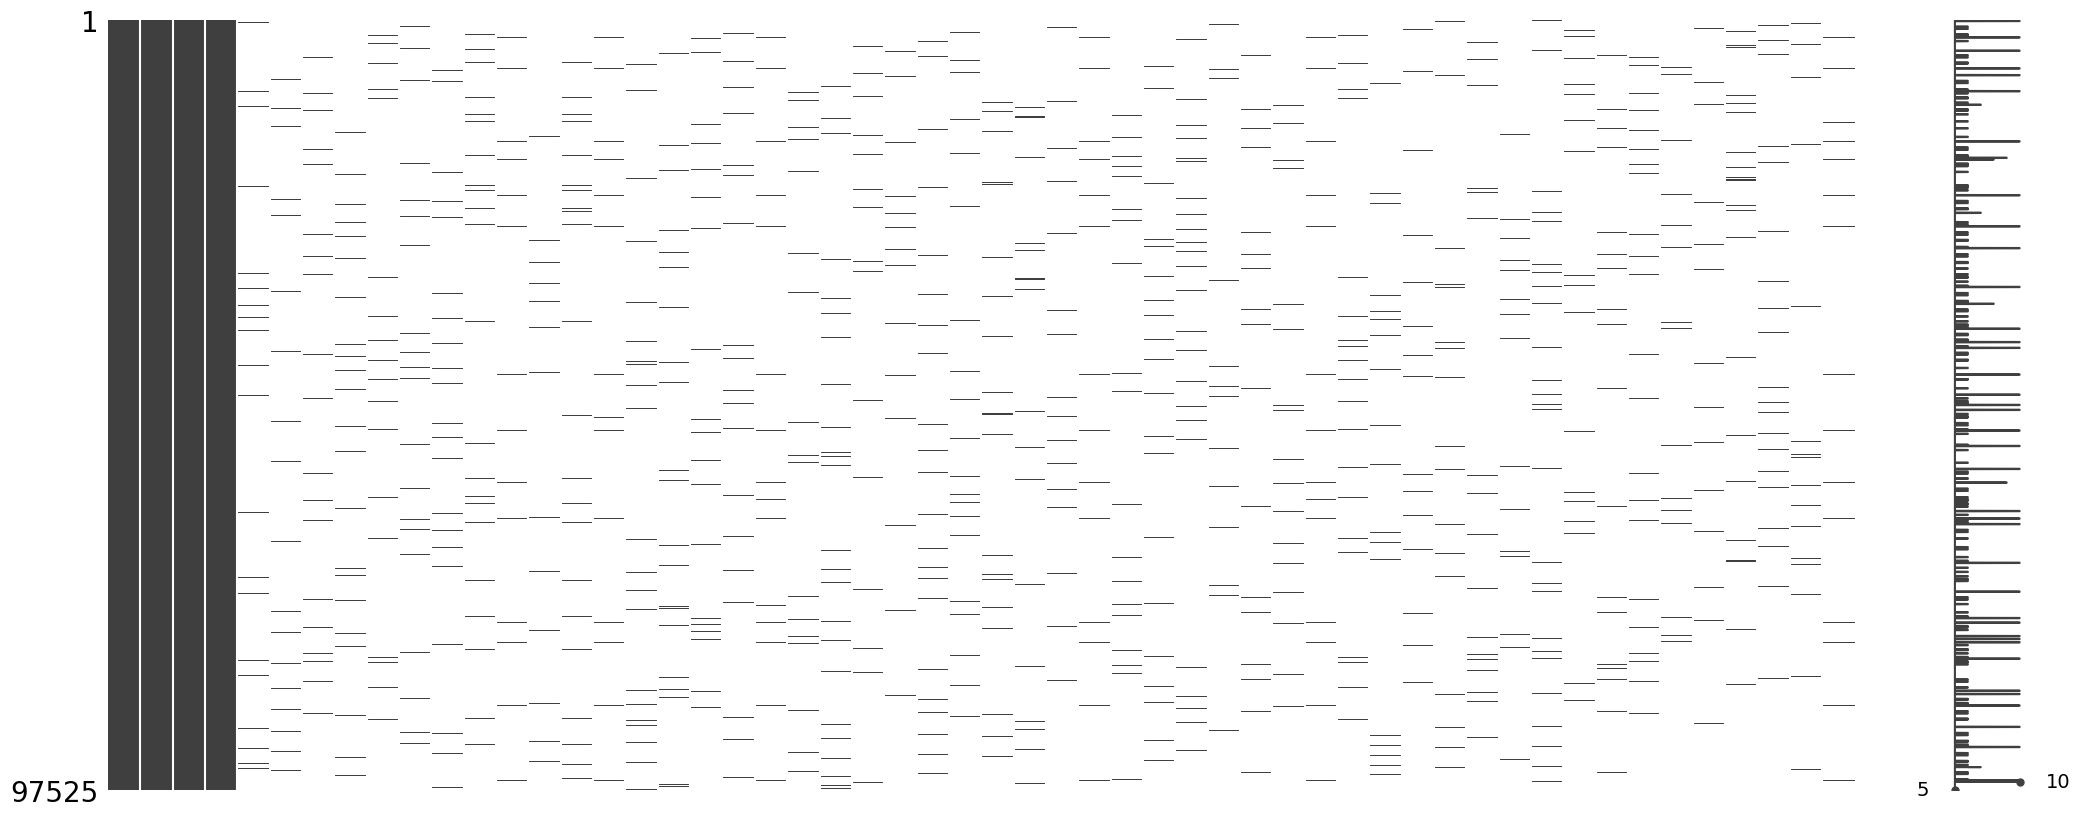

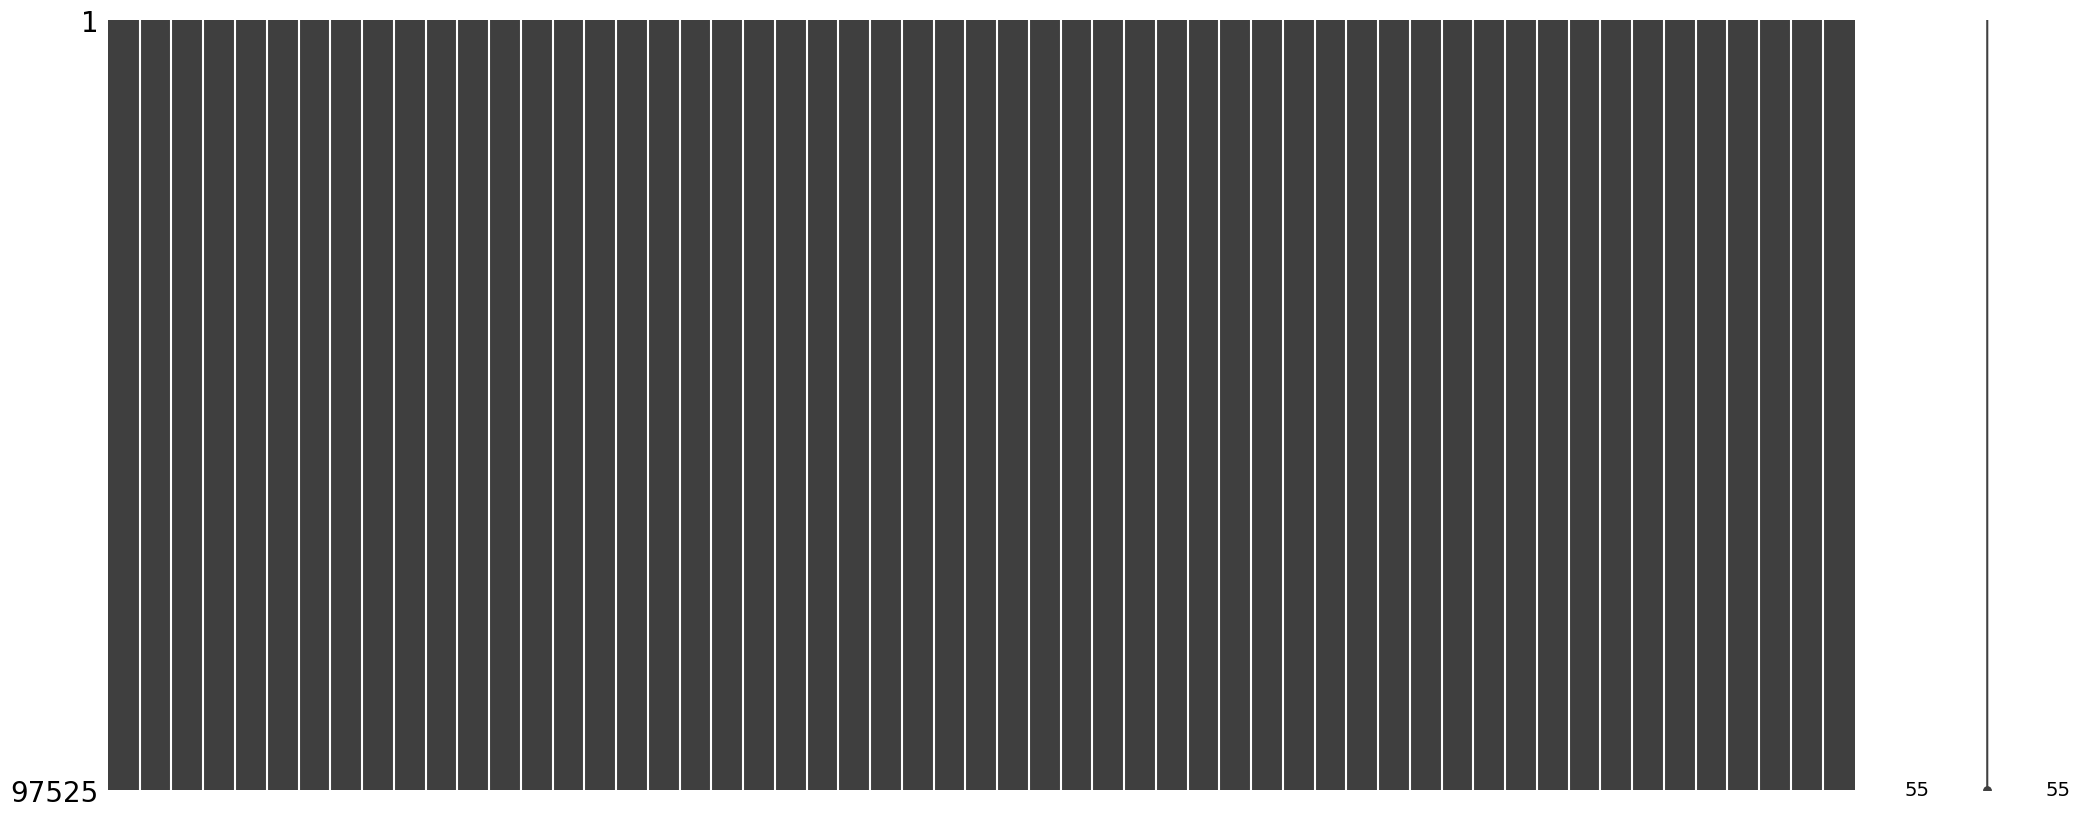

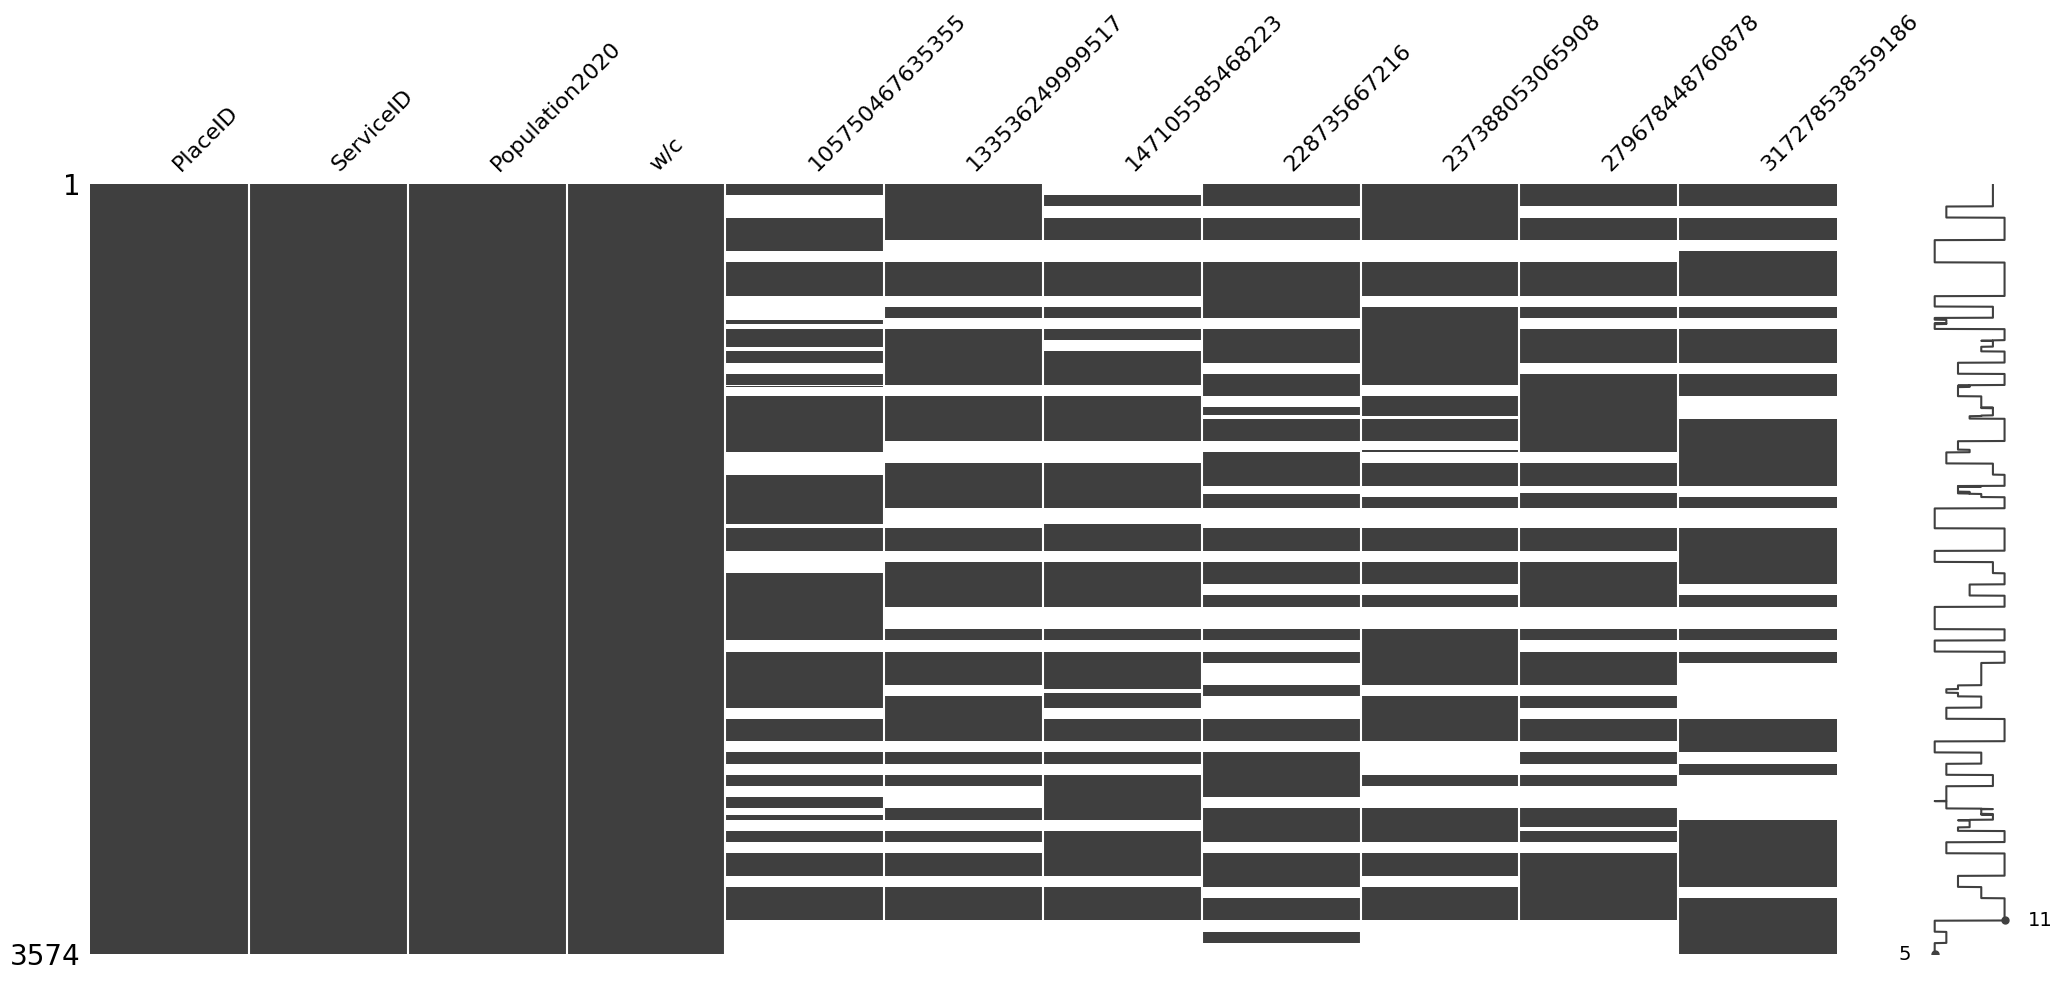

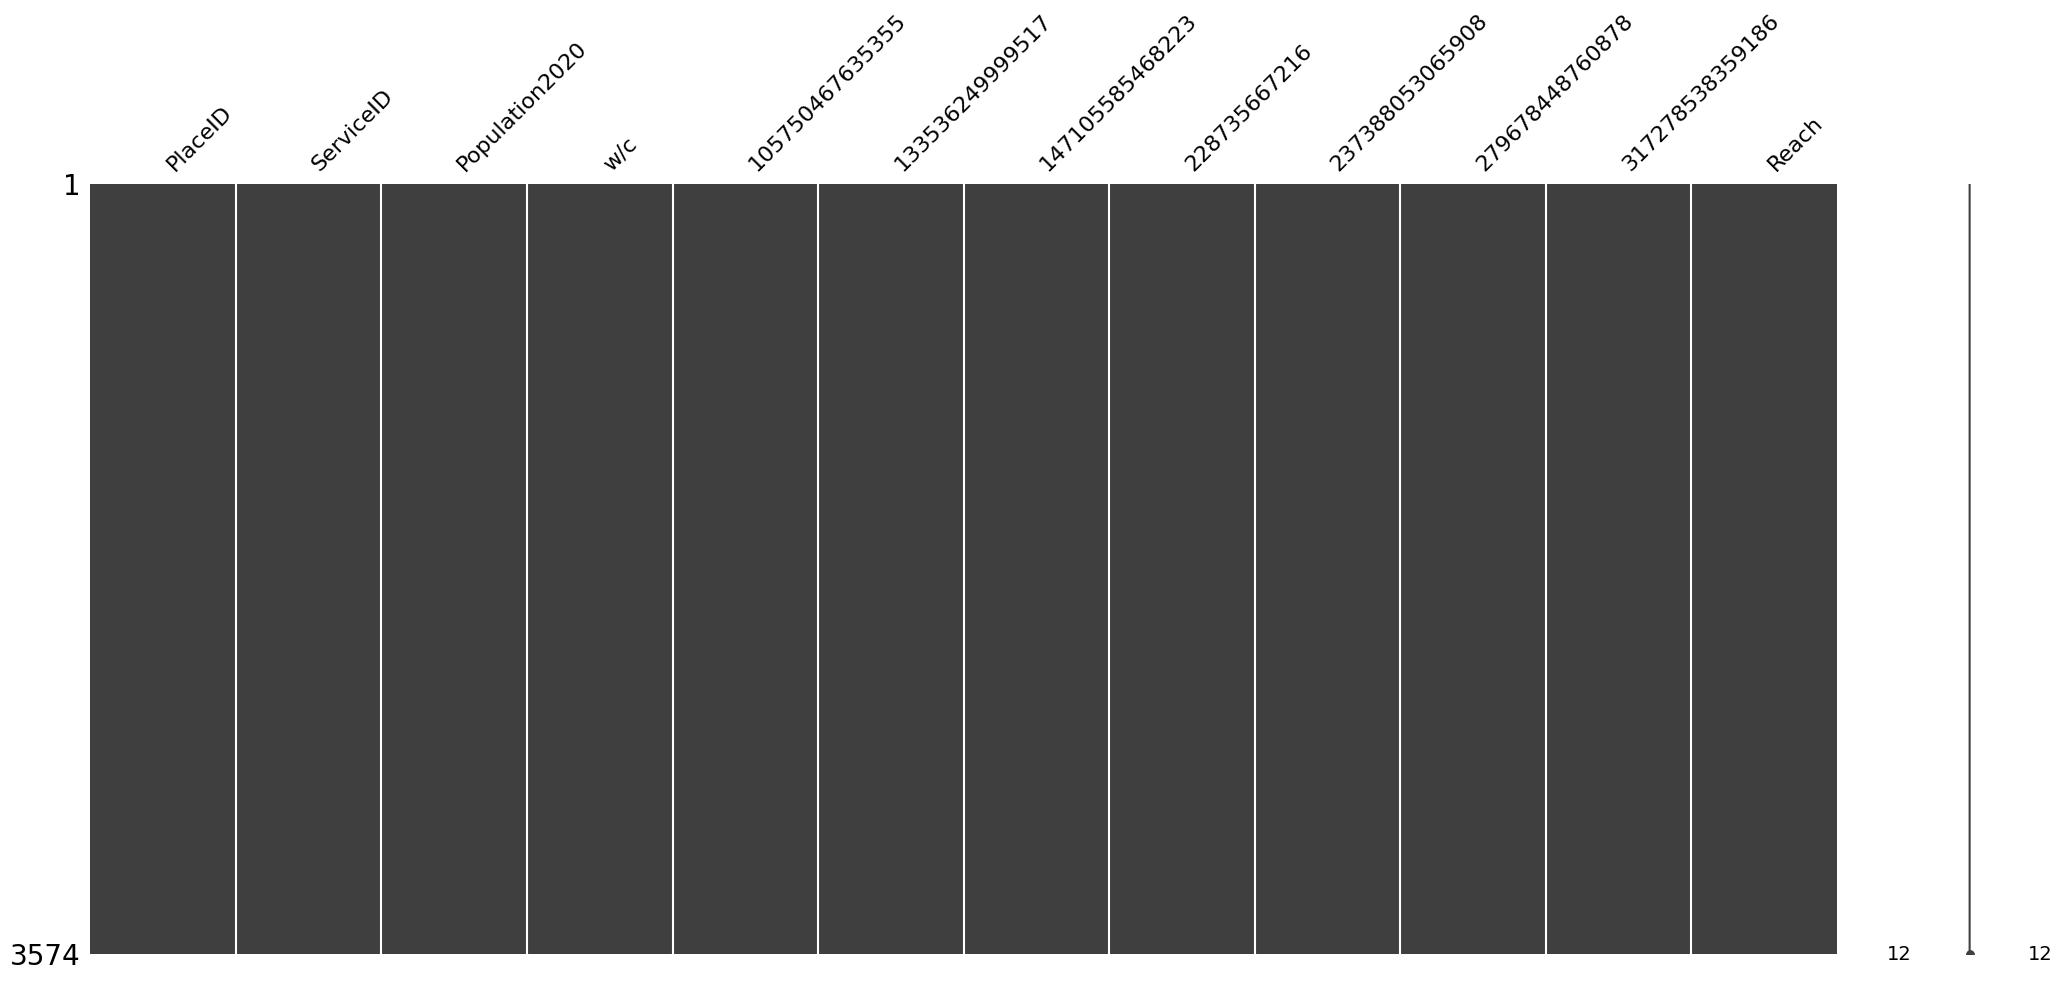

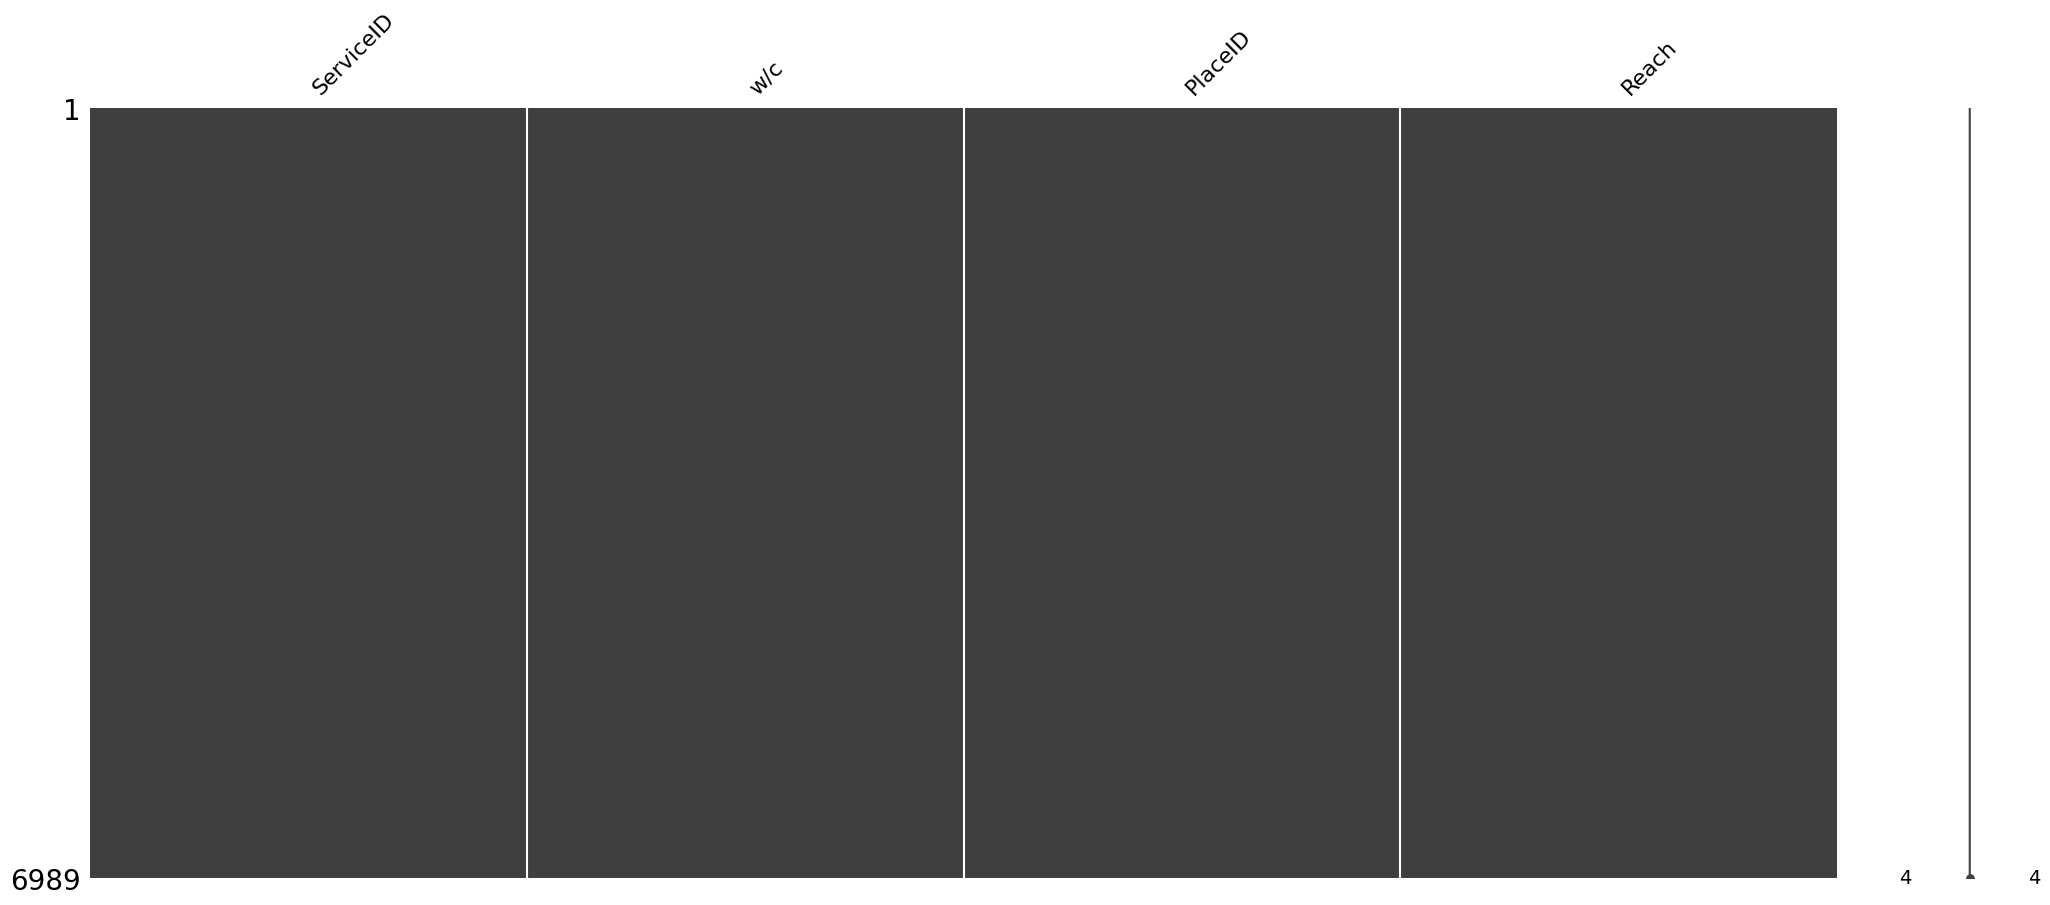

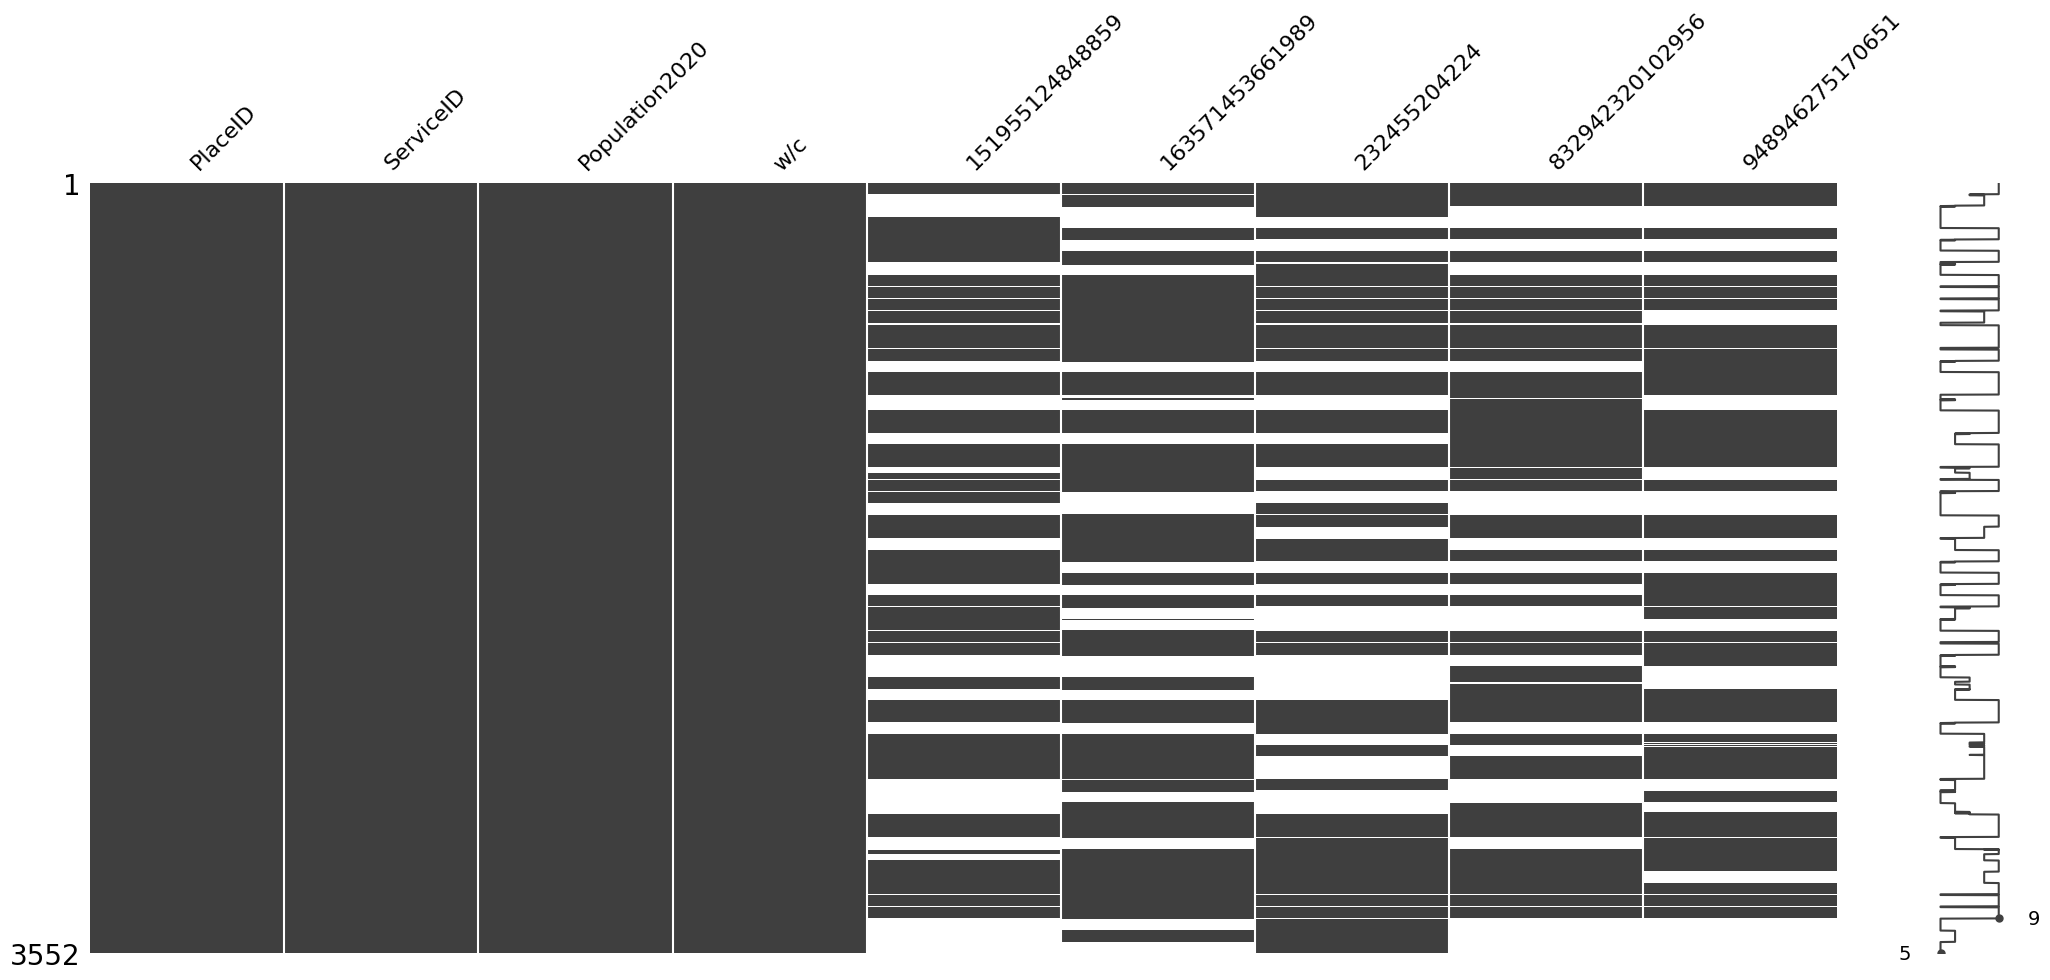

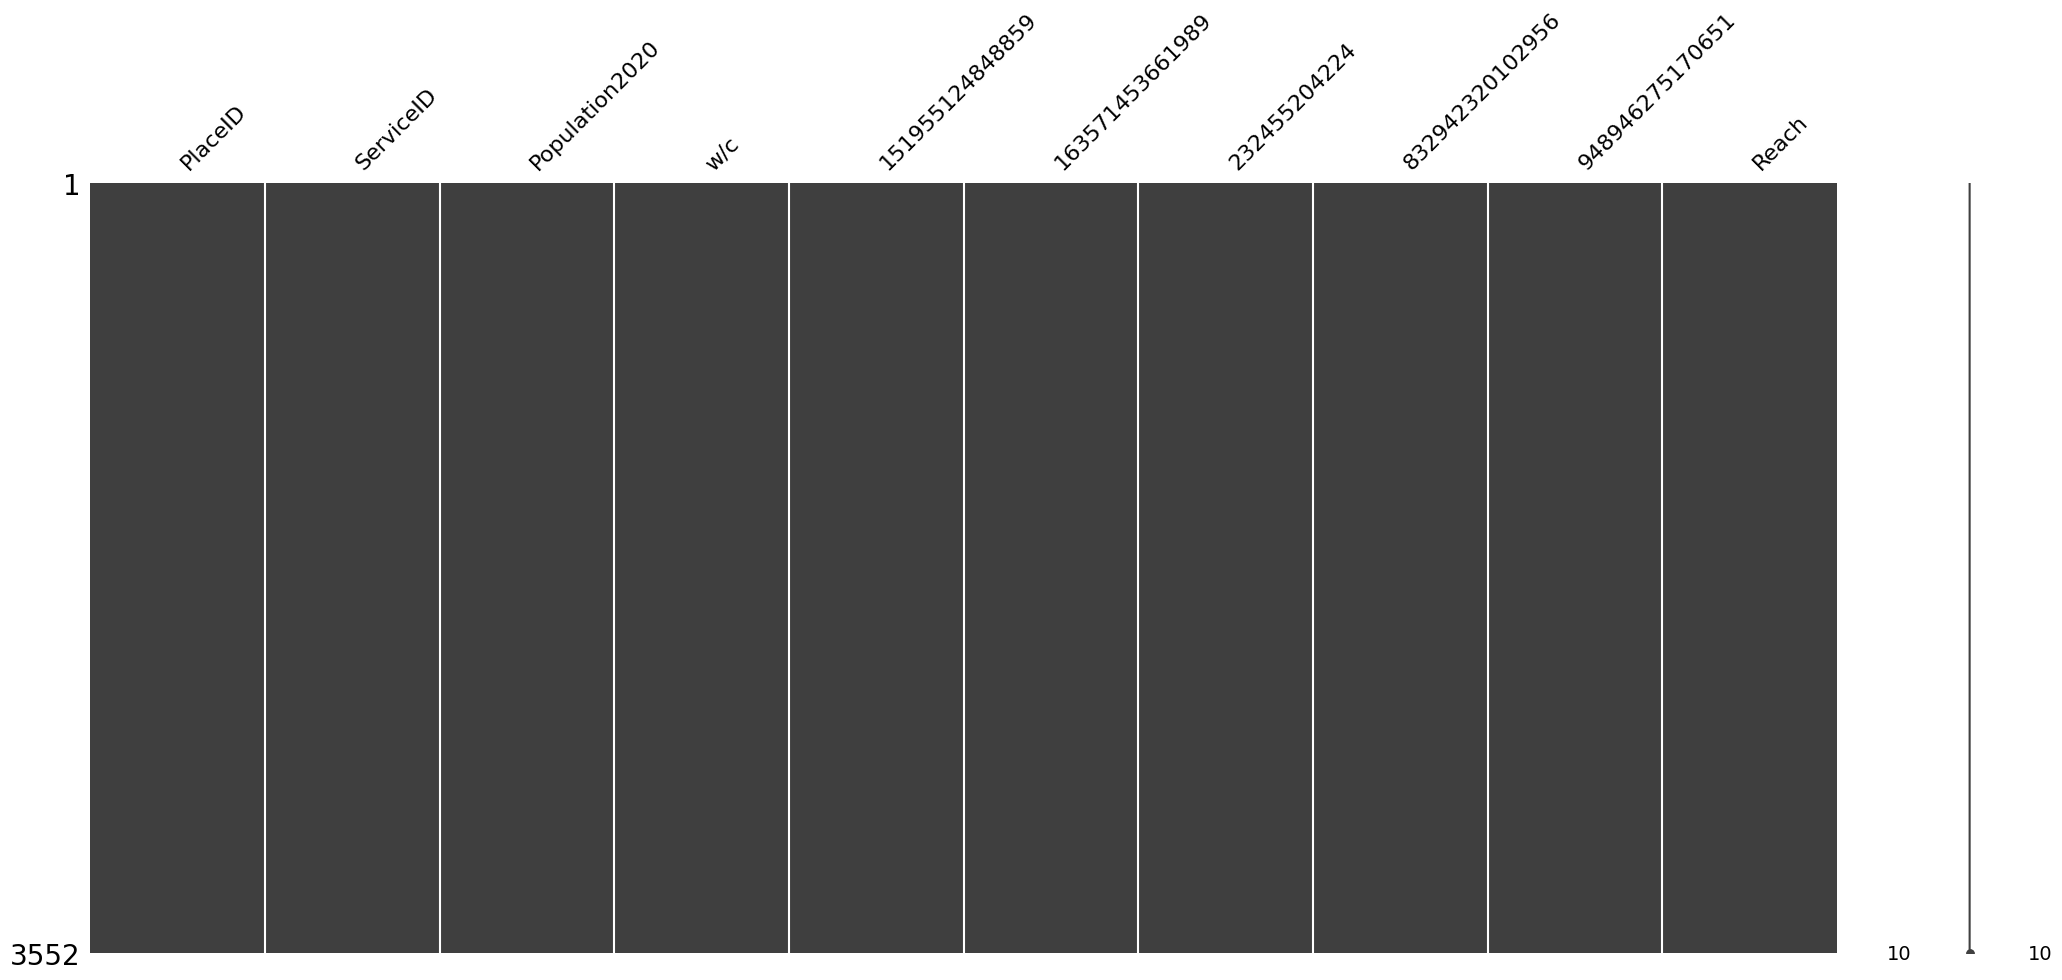

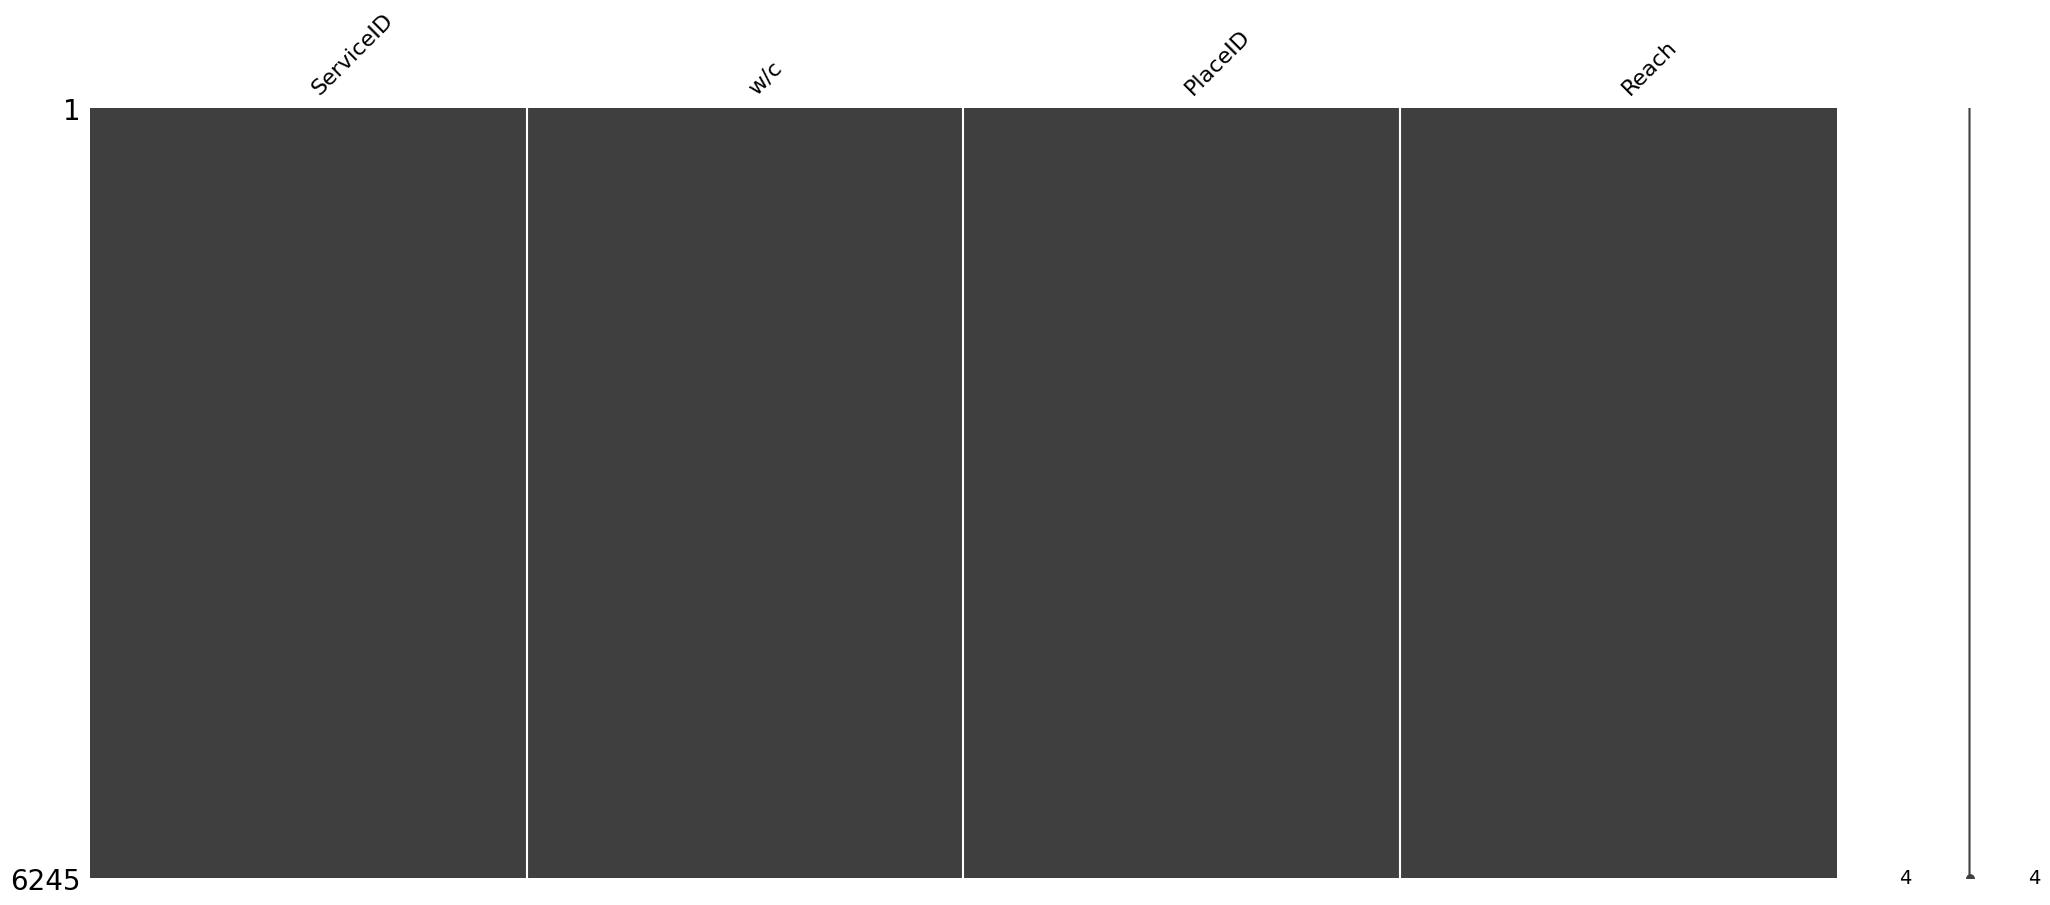

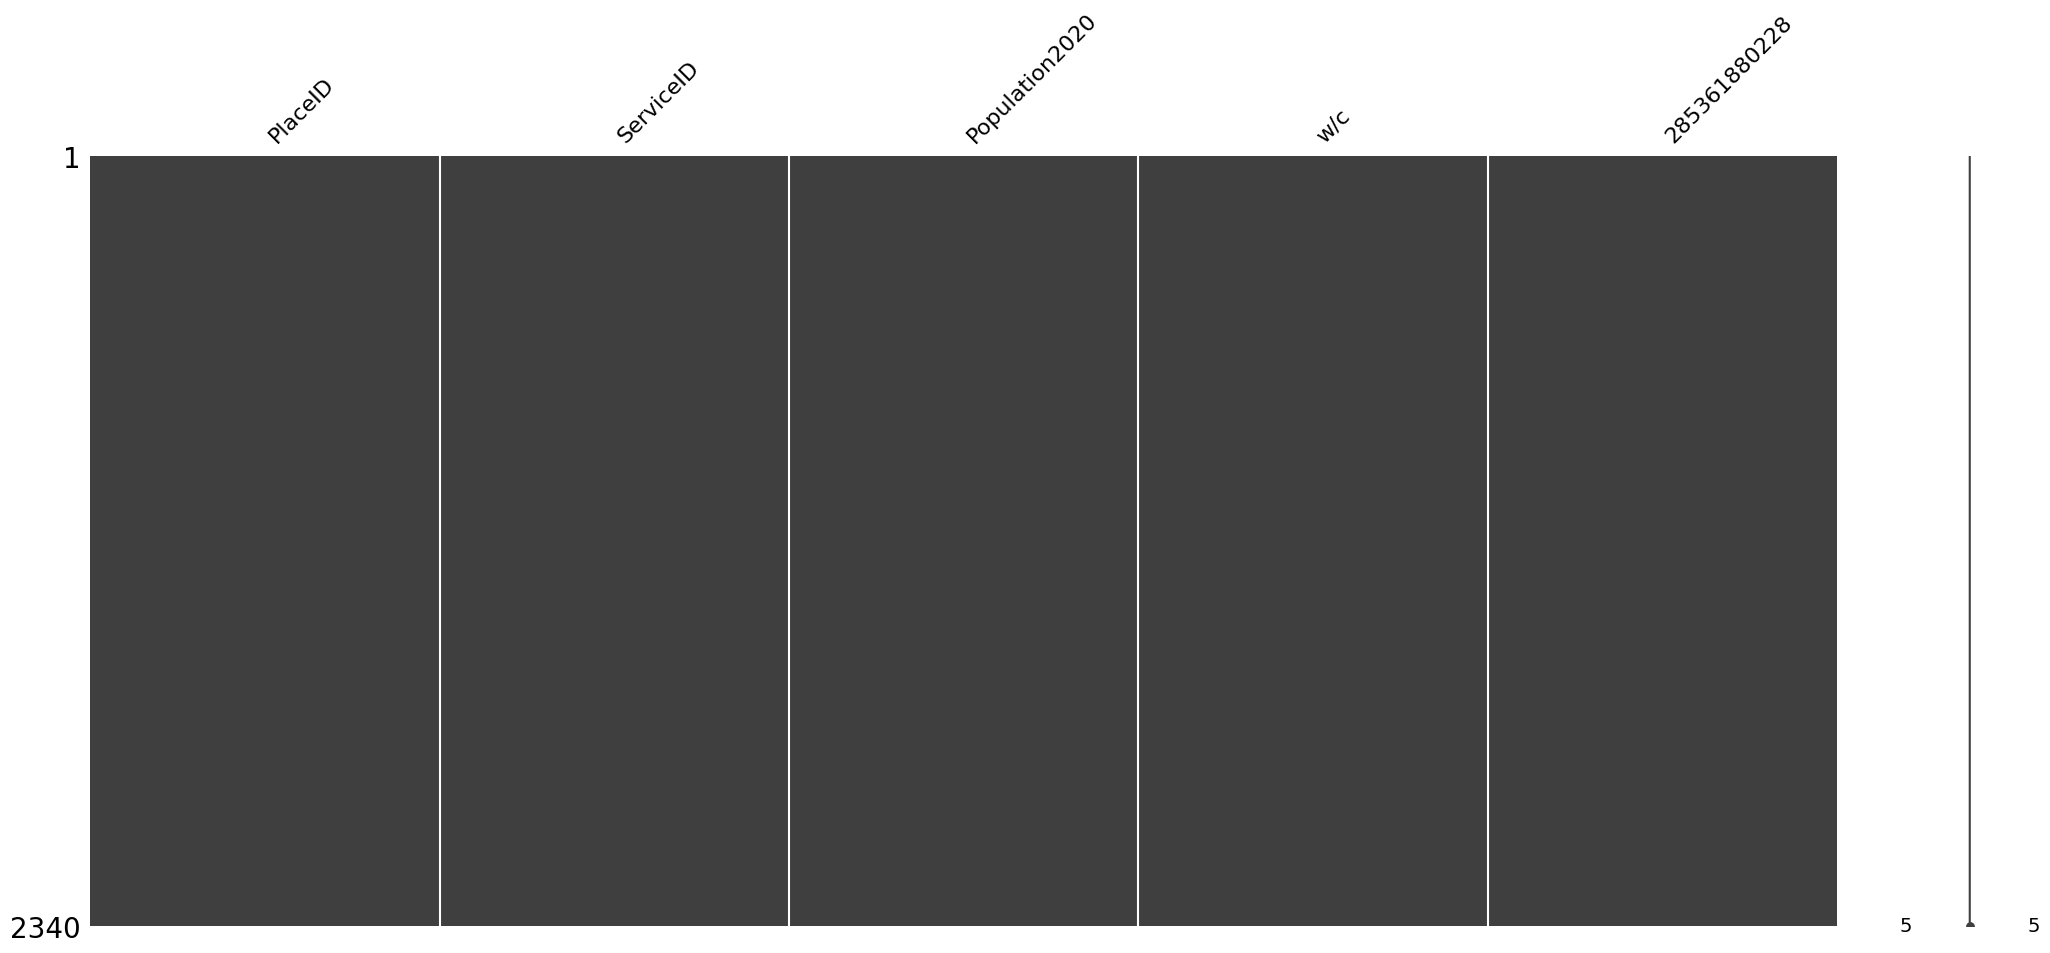

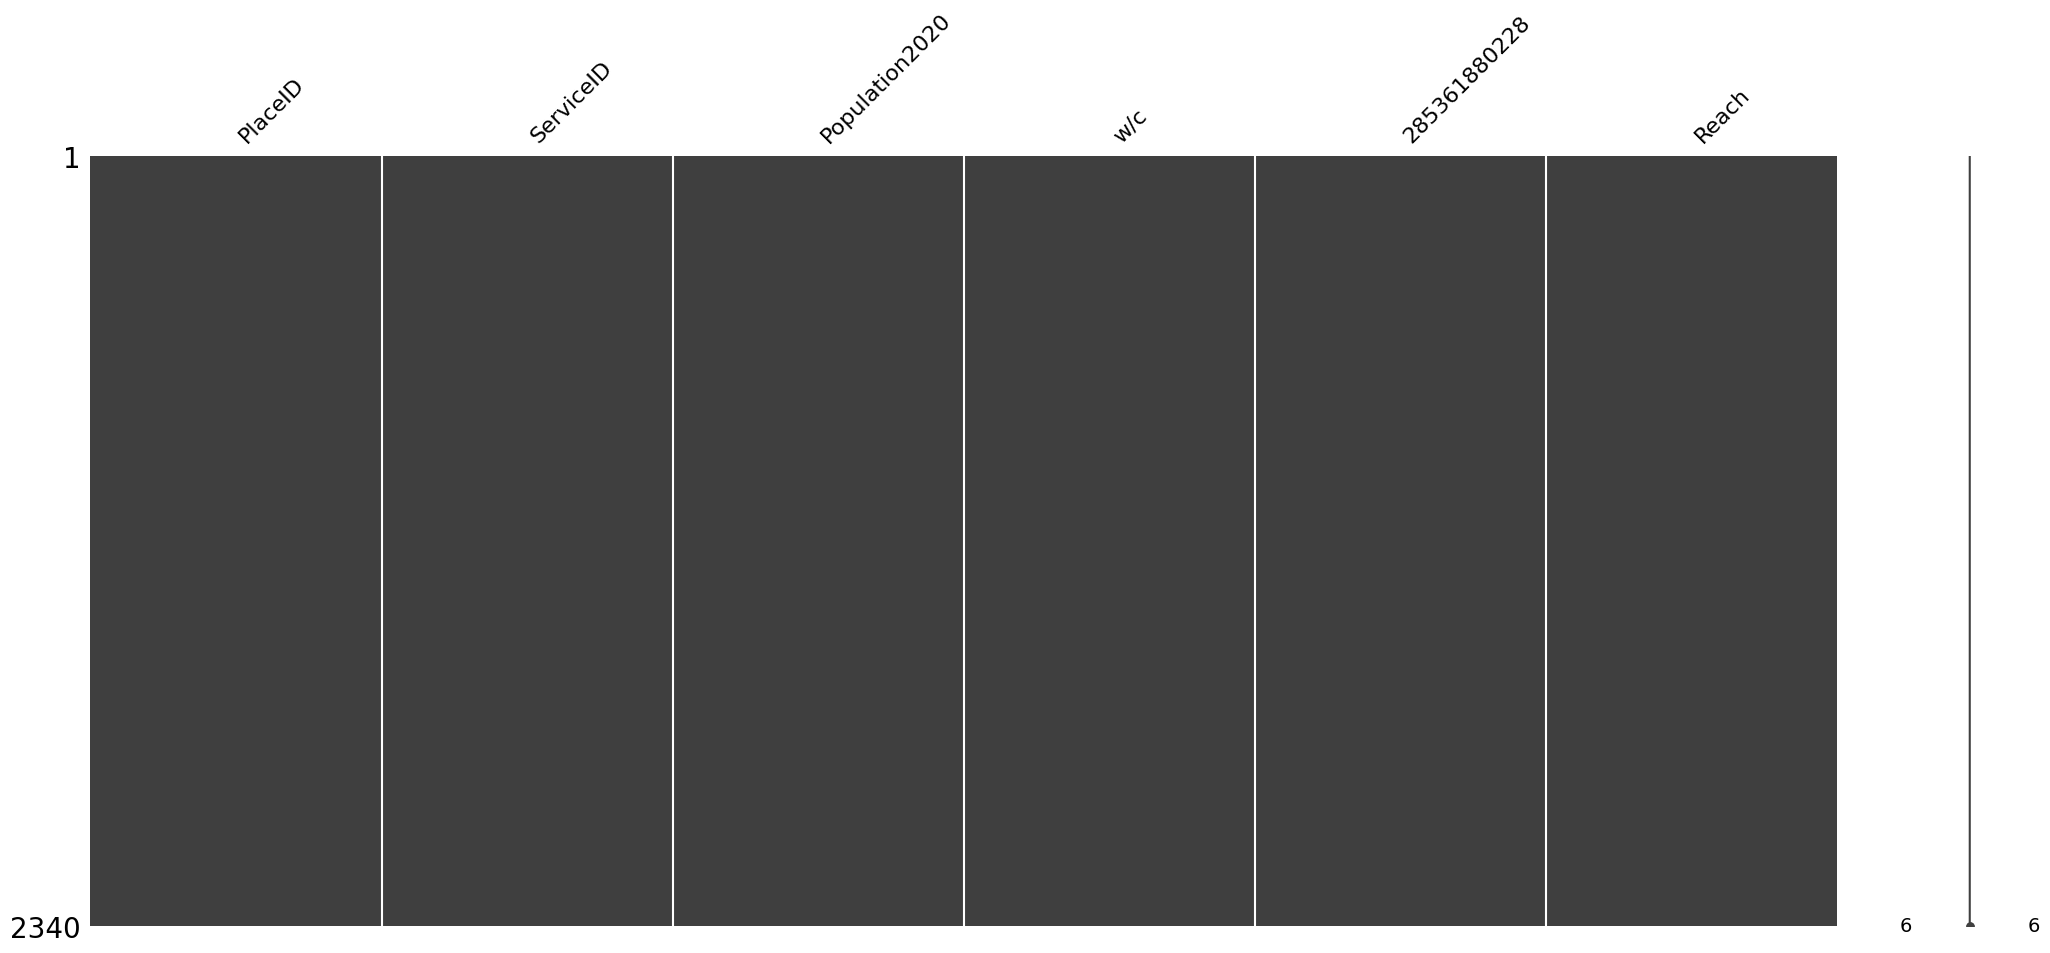

In [8]:

data = {}
'''temp_bus = ['GNL', 'WSL', 'GNL','Studios', 'WSE', 'MA-', 'FOA']
for bu in temp_bus:
'''#
for bu in gam_info['business_units'].keys():
    print(f"### processing {bu} ######################################################")
    data[bu] = {'weekly': 'tbd', 
                #'annual': 'tbd'
               }
    
    bu_configs = gam_info['business_units'][bu]
    print(bu_configs)
    df = full_df[full_df['ServiceID'].isin(gam_info['business_units'][bu]['Service IDs'])]
    
    if df.empty:
        print(f"no data yet for {bu}")
        
    channel_ids = df['Channel ID'].unique().tolist()
    
    # will include / exclude the uk based on bu_configs
    df = functions.include_uk_decision(df, socialmedia_accounts)
    
    # for later testing or if sainsbury isn't used 
    summed_uv_by_country = df.groupby(['ServiceID', 'w/c', 'PlaceID'])\
                                .agg({'uv_by_country': 'sum'})\
                                .reset_index()
    
    if bu_configs['sainsbury'][platformID]:
        print('sainsbury is applied')
        # pivot 
        channel_uv_by_country = pd.crosstab(
                                        index = [ df['PlaceID'], 
                                                  df['ServiceID'], 
                                                  df[pop_size_col], 
                                                  df['w/c']],
                                        columns = df['Channel ID'],
                                        values =  df['uv_by_country'],
                                        aggfunc='sum'
                                    ).reset_index()
    
        # check for missing values
        # especially in the string columns no values should be missing
        msno.matrix(channel_uv_by_country)
        
        # fill missing values with 0 - this is good fi the matrix above showed that the string 
        # columns did not have any missings so the only gaps filled are numeric. 
        channel_uv_by_country = channel_uv_by_country.fillna(0)
        
        #calculate sainsbury
        channel_uv_by_country = functions.sainsbury_formula(channel_uv_by_country, pop_size_col, 
                                      channel_ids, 'uv_by_country')
        
        cols_left =  ['w/c', 'PlaceID', 'uv_by_country']
        cols_right = ['w/c', 'PlaceID', 'ServiceID', 'uv_by_country']
        #yt_deduped = channel_uv_by_country[cols_left].merge(summed_uv_by_country[cols_right], on=['w/c', 'PlaceID'], how='inner')
        yt_deduped = channel_uv_by_country.rename(columns={'uv_by_country': 'Reach'})
        
    else:
        print('sainsbury is skipped ')
        # instead of pivot we can use the summed df above that already contains the sum over 
        # YT Service Code so the channels are already summarised in Services
        yt_deduped = summed_uv_by_country.rename(columns={'uv_by_country': 'Reach'})
    
    # processing 
    weekly_df= functions.summary_excel(yt_deduped, bu, platformID, gam_info)
    
    # storing data
    data[bu]['weekly'] = weekly_df
    #data[bu]['annual'] = annual_df
    
    

In [14]:
full_df[(full_df['ServiceID'] == 'WSE') & 
    (full_df['w/c'] == '2025-02-03') & 
    (full_df['PlaceID'] == 'IND')]

,w/c,PlaceID,ServiceID,Channel ID,uv_by_country,Population2020
175201,2025-02-03,IND,WSE,151955124848859,145782,350038199
210075,2025-02-03,IND,WSE,163571453661989,12855,350038199
316329,2025-02-03,IND,WSE,232455204224,1,350038199
519497,2025-02-03,IND,WSE,832942320102956,27,350038199
535877,2025-02-03,IND,WSE,948946275170651,894,350038199


In [16]:
bu_df = data['WSE']['weekly']
bu_df[(bu_df['ServiceID'] == 'WSE') & 
    (bu_df['w/c'] == '2025-02-03') & 
    (bu_df['PlaceID'] == 'IND')]

Channel ID,YearGAE,ServiceID,PlatformID,PlaceID,w/c,Reach
1093,2025,WSE,FBE,IND,2025-02-03,159554


## AXE

In [11]:
grouped_service = 'AXE'
data[grouped_service] = {'weekly': pd.DataFrame()}
    

### weekly 

In [12]:

wsl_weekly = data['WSL']['weekly']
wsl_weekly = wsl_weekly[~wsl_weekly['ServiceID'].isin(['SER', 'SIN'])]

data[grouped_service]['weekly'] = functions.calculate_weekly_sumServices(wsl_weekly, grouped_service, platformID, gam_info)


## AX2, ANW, ANY, TOT, ALL, ENG, EN2 ENW


In [13]:
path = f"../data/singlePlatform/{platformID}/"
stages = [
        # (grouped_service, service1, service2, overlap_type, overlap_service_id, use_v2, optional_service3)
        ('AX2', 'FOA', 'AXE', 'WSL/FOA', 'FOA', False, None),
        ('ANW', 'AX2', 'WSE', 'WSE/WSL', 'AXE', False, None),
        ('ANY', 'GNL', 'ANW', 'WSL/GNL', 'ANW', False, None),
        ('TOT', 'MA-', 'ANY', 'sainsbury', '-', False, None),
        ('ALL', 'TOT', 'WOR', 'sainsbury', '-', False, None),
        ('ENG', 'GNL', 'WSE', 'sainsbury', '-', False, None),
        ('EN2', 'GNL', 'WSE', 'other', '-', True, 'WOR'),
        ('ENW', 'WSE', 'FOA', 'sainsbury', '-', False, None)
    ]
data = functions.calculate_aggregated_services(data, stages, platformID, gam_info, path, overlaps, 
                                                country_codes, pop_size_col)


overlap applied: 0.035686
calculating annual by the new method
overlap applied: 0.071933
calculating annual by the new method
overlap applied: 0.106934
calculating annual by the new method
adding population: _merge
both          8404
left_only        0
right_only       0
Name: count, dtype: int64
calculating annual by the new method
adding population: _merge
both          9132
left_only        0
right_only       0
Name: count, dtype: int64
calculating annual by the new method
adding population: _merge
both          3930
left_only        0
right_only       0
Name: count, dtype: int64
calculating annual by the new method
calculating annual by the new method
adding population: _merge
both          3777
left_only        0
right_only       0
Name: count, dtype: int64
calculating annual by the new method
